# Chesspiece and color detection using OpenCV

In [105]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

The method below tries to detect a chess piece on a tile. It removes some of the border of the image to prevent detecting a piece that is overlapping this tile that van happen when the camera is mounted close to the chessboard. This way it will only detect pieces which are close to the center of the detected tile.

In [106]:
def detect_piece(image):
    plt.gcf().set_size_inches(15, 15)
    plt.subplot(3, 3, 1)
    plt.title('Original')
    plt.axis('off')
    plt.imshow(image)


    # Check if there are any contours in the cell, if there are then there is a piece on the cell
    # Only check in the center of the cell to avoid detecting the edges of the cell as pieces
    padding = image.shape[1] // 4
    region = image[padding:-padding, padding:-padding]

    plt.subplot(3, 3, 2)
    plt.title('Region')
    plt.axis('off')
    plt.imshow(region)

    
    gray = cv2.cvtColor(region, cv2.COLOR_RGB2GRAY)

    plt.subplot(3, 3, 3)
    plt.title('Gray')
    plt.axis('off')
    plt.imshow(gray, cmap='gray')

    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    plt.subplot(3, 3, 4)
    plt.title('Blurred')
    plt.axis('off')
    plt.imshow(blurred, cmap='gray')

    canny = cv2.Canny(blurred, 50, 100, apertureSize=3)

    plt.subplot(3, 3, 5)
    plt.title('Canny')
    plt.axis('off')
    plt.imshow(canny, cmap='gray')


    contours, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    isWhite = False

    if len(contours) > 0:
        all_points = np.vstack(contours)
        merged = cv2.convexHull(all_points)

        _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

        plt.subplot(3, 3, 6)
        plt.title('Threshold')
        plt.axis('off')
        plt.imshow(thresh, cmap='gray')

        piece = np.zeros_like(gray)
        cv2.drawContours(piece, [merged], -1, (255), cv2.FILLED)
        plt.subplot(3, 3, 7)
        plt.title('Piece Contour')
        plt.axis('off')
        plt.imshow(piece, cmap='gray')

        piece = cv2.bitwise_and(thresh, piece)

        plt.subplot(3, 3, 8)
        plt.title('Piece')
        plt.axis('off')
        plt.imshow(piece, cmap='gray')

        white_ratio = cv2.countNonZero(piece) / (image.shape[0] * image.shape[1])
        isWhite = white_ratio > 0.05

        cv2.drawContours(image[padding:-padding, padding:-padding], [merged], -1, (255, 255, 255) if isWhite else (0,0,0), cv2.FILLED)

    plt.subplot(3, 3, 9)
    plt.title('Final')
    plt.imshow(image)
    plt.axis('off')
    plt.show()

Detecting a image of a black rook will draw a black contour part of the rook in the image

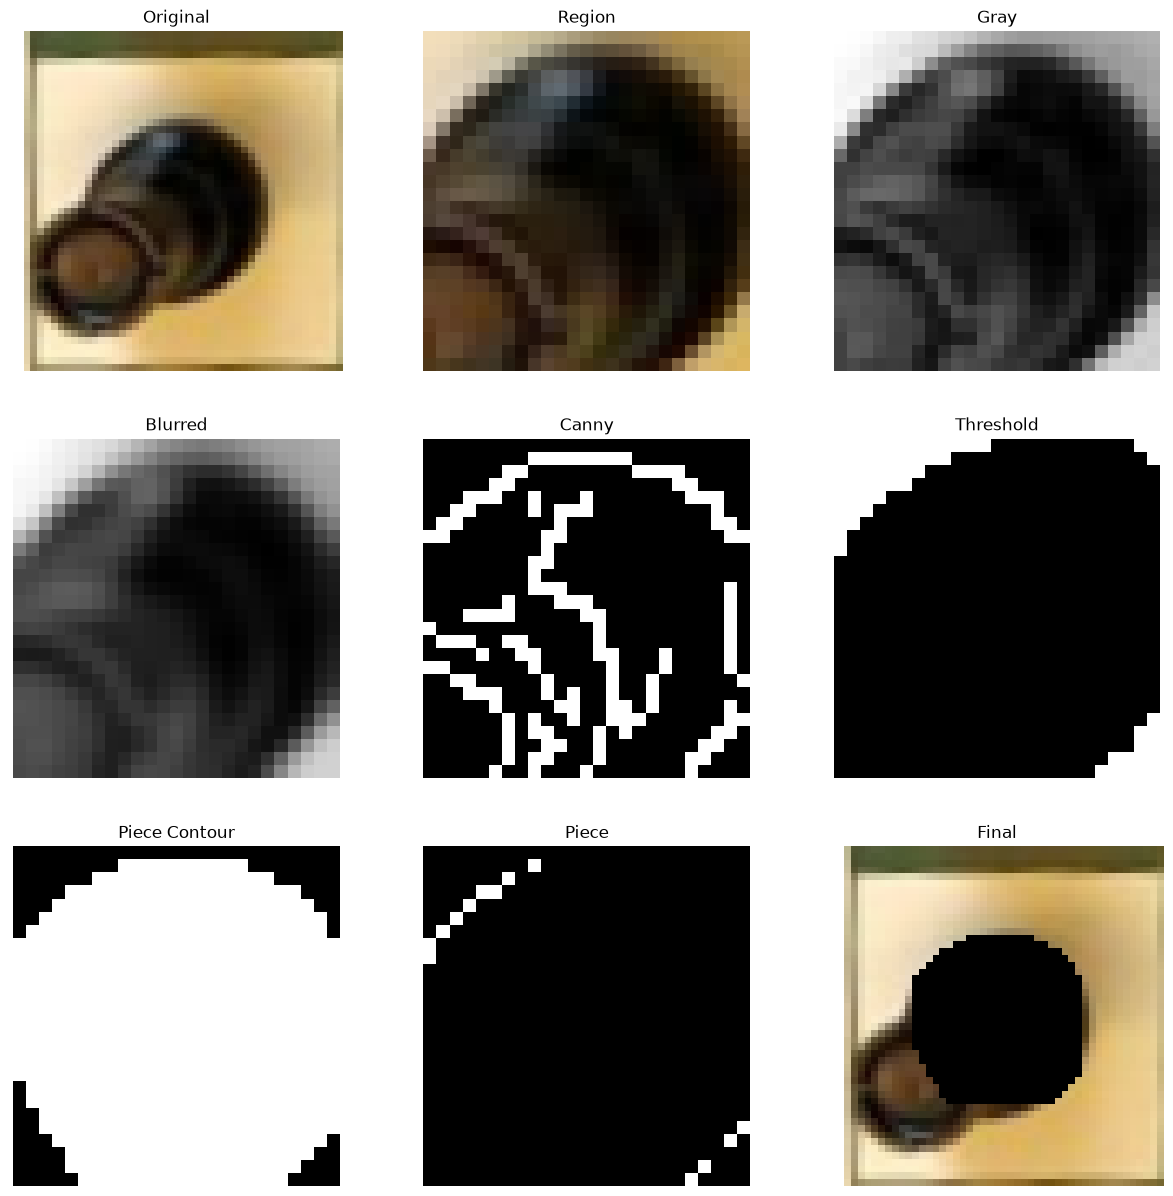

In [107]:
image = cv2.imread('../tile_detection/out/a1.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
detect_piece(image)

Detecting a image of a white rook will draw a white contour part of the rook in the image

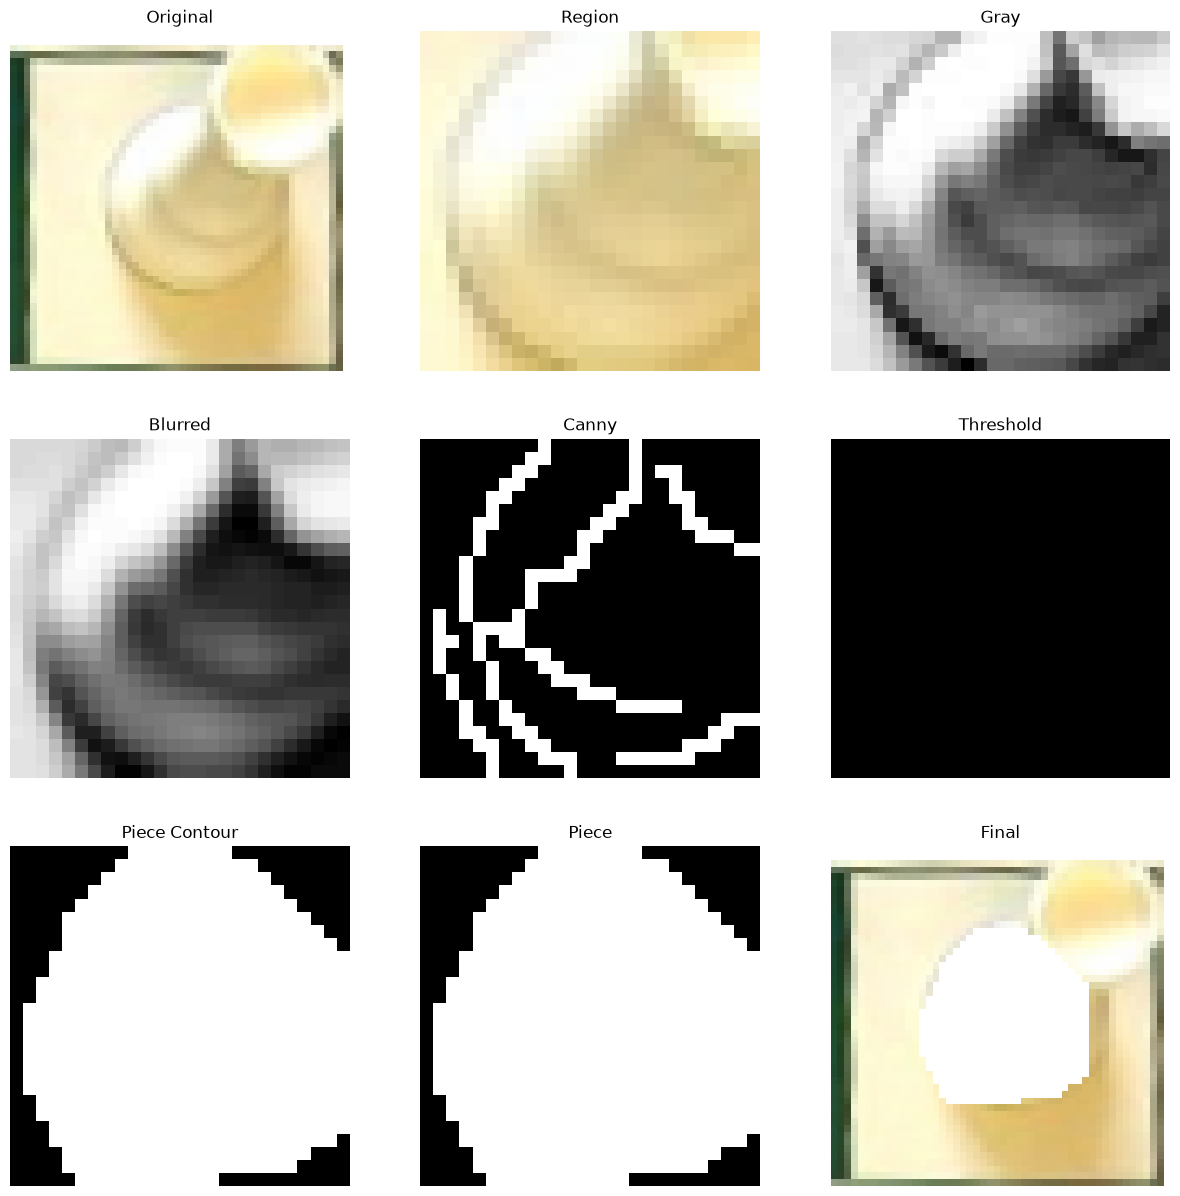

In [108]:
image = cv2.imread('../tile_detection/out/h8.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
detect_piece(image)

Detecting a image of a black queen will draw a black contour part of the queen in the image

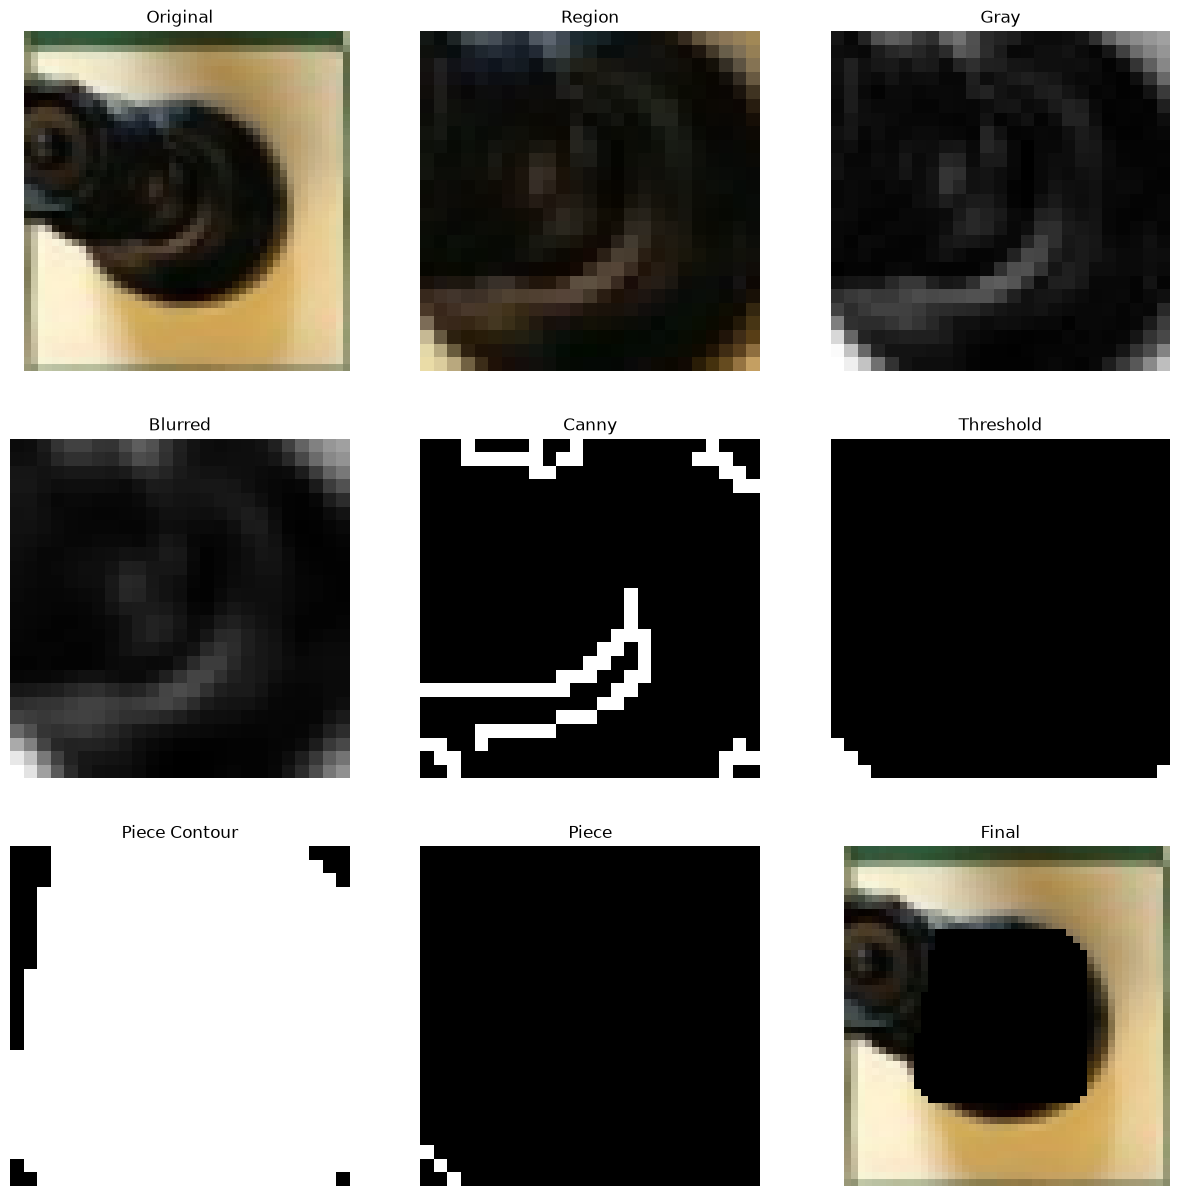

In [109]:
image = cv2.imread('../tile_detection/out/a5.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
detect_piece(image)

Detecting a image of a white queen will draw a white contour part of the queen in the image

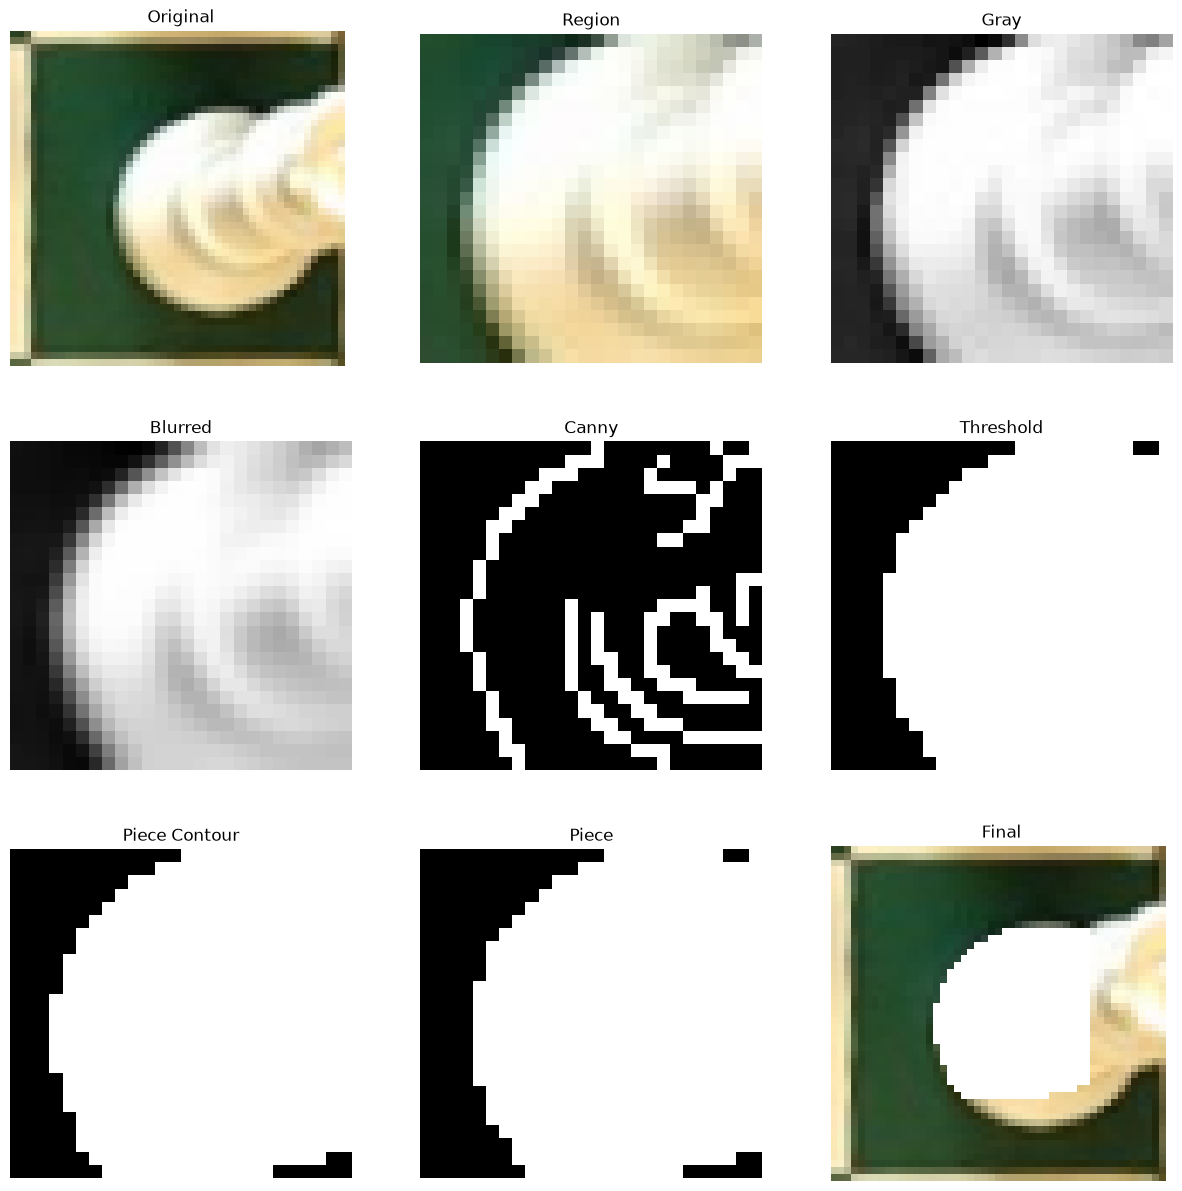

In [110]:
image = cv2.imread('../tile_detection/out/h5.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
detect_piece(image)